# USA Housing Insights

*The USA Housing dataset was analyzed to identify patterns and factors influencing house prices across different locations in the United States. Exploratory Data Analysis (EDA) was performed to understand the distribution of variables, detect outliers, and examine relationships between housing features and price.*

IMPORTING LIBRARIES

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df=pd.read_csv(r"C:\DATA ANALYTICS\DA WITH PYTHON\USA_Housing (address).csv")

Top 5 Rows Of Dataset

In [36]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [38]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562390,5.322283,6.299250,3.140000,29403.928700,9.975771e+05
50%,68804.286405,5.970429,7.002902,4.050000,36199.406690,1.232669e+06
75%,75783.338665,6.650808,7.665871,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


In [39]:
df.shape

(5000, 7)

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

In [42]:
df=df.drop(["Avg. Area Number of Bedrooms","Address"],axis=1)

In [55]:
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Area Population,Price
0,79545.45857,5.682861,7.009188,23086.80050,1.059034e+06
1,79248.64245,6.002900,6.730821,40173.07217,1.505891e+06
2,61287.06718,5.865890,8.512727,36882.15940,1.058988e+06
3,63345.24005,7.188236,5.586729,34310.24283,1.260617e+06
4,59982.19723,5.040555,7.839388,26354.10947,6.309435e+05
...,...,...,...,...,...
4995,60567.94414,7.830362,6.137356,22837.36103,1.060194e+06
4996,78491.27543,6.999135,6.576763,25616.11549,1.482618e+06
4997,63390.68689,7.250591,4.805081,33266.14549,1.030730e+06
4998,68001.33124,5.534388,7.130144,42625.62016,1.198657e+06


# DATA PREPROCESSING

## Missing Value Handling:

In [43]:
df.isnull().sum()

Avg. Area Income             0
Avg. Area House Age          0
Avg. Area Number of Rooms    0
Area Population              0
Price                        0
dtype: int64

## Outlier Handling:

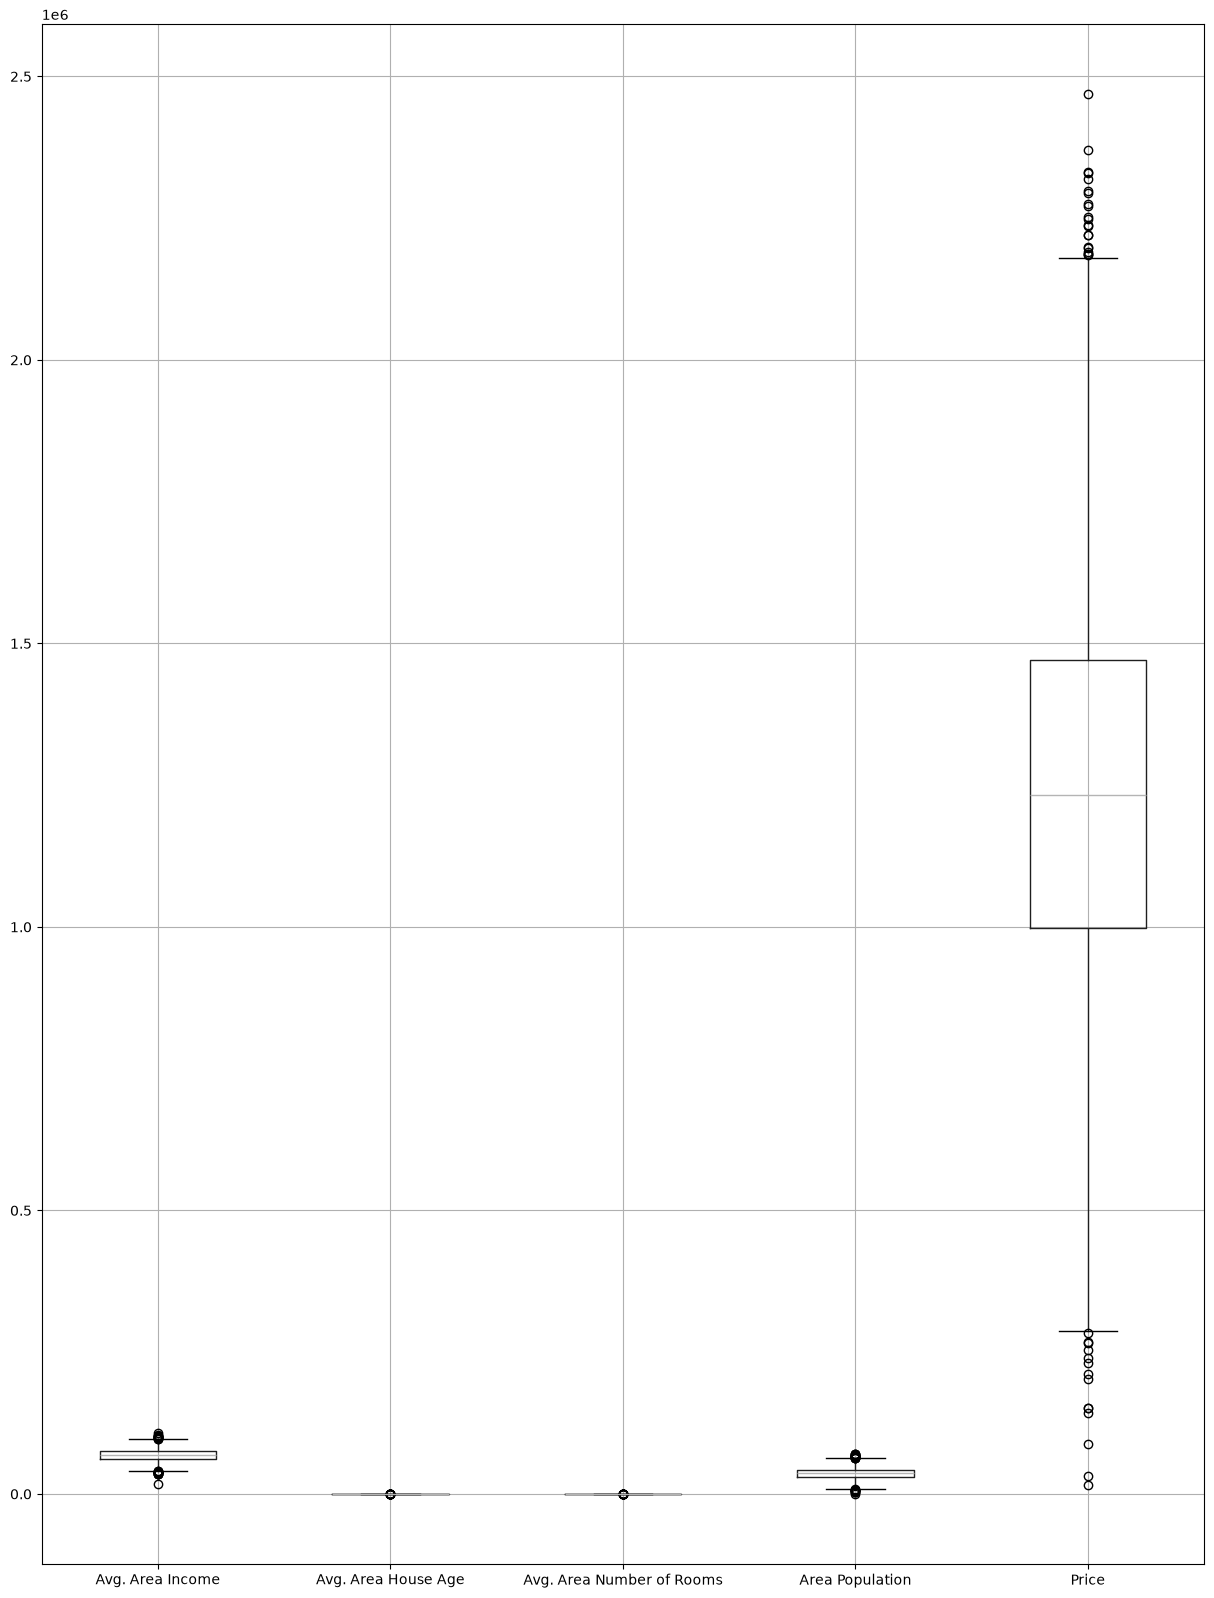

In [44]:
plt.figure(figsize=(15,20))
df.boxplot()
plt.show()

In [45]:
#Clipping
for i in ["Avg. Area Income","Area Population","Price"]:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df[i]=df[i].clip(lower,upper)

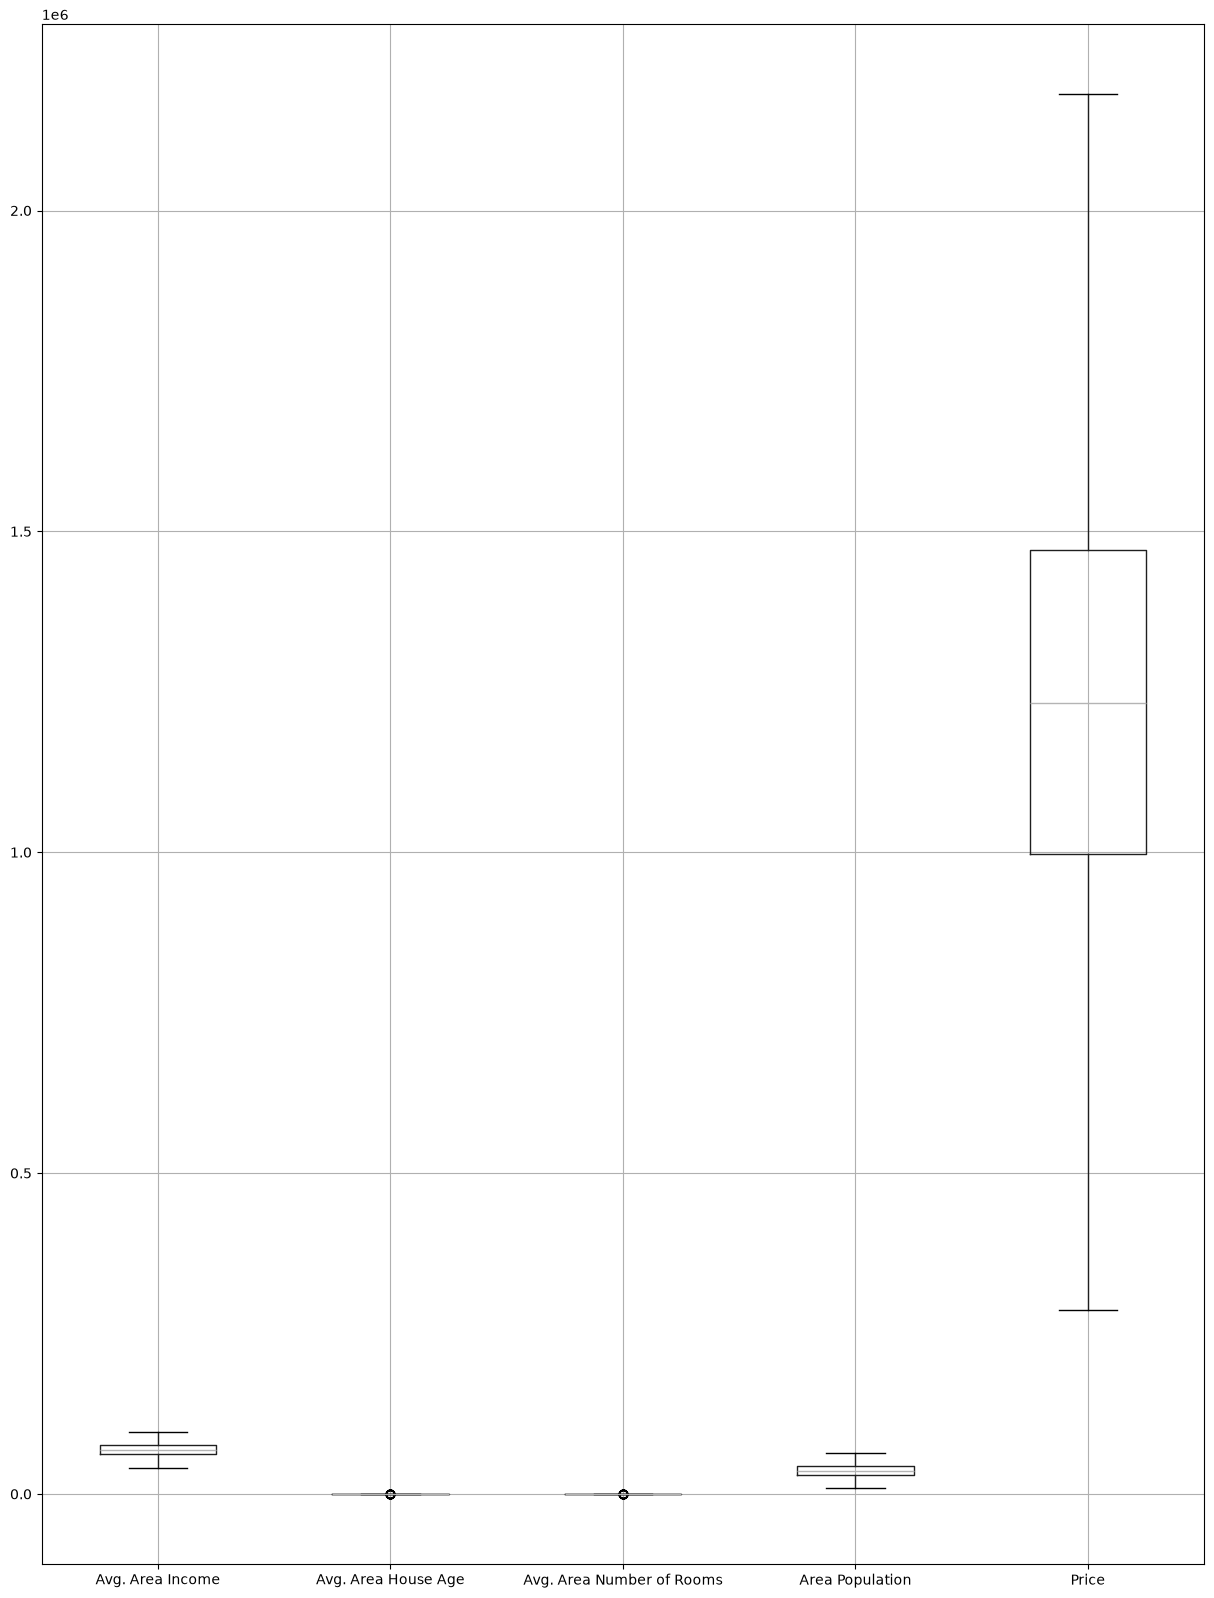

In [46]:
plt.figure(figsize=(15,20))
df.boxplot()
plt.show()

## Univariate Analysis

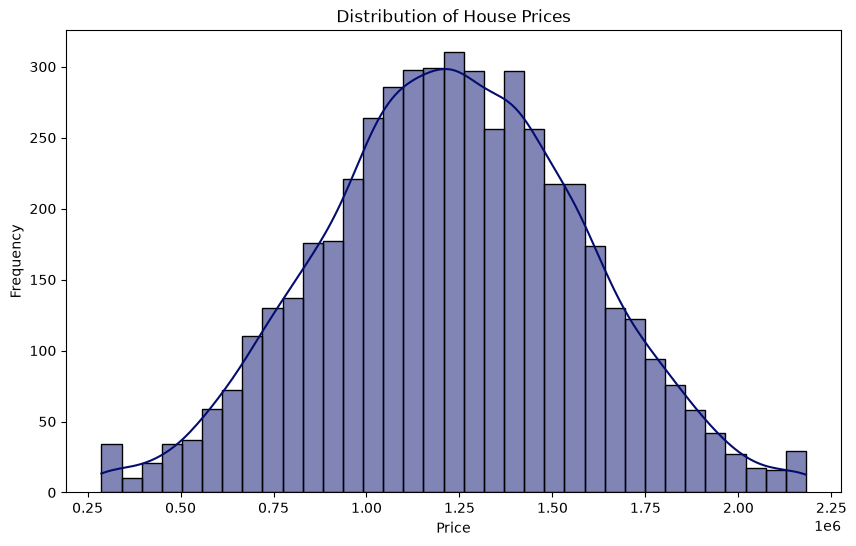

In [51]:
plt.figure(figsize=(10,6))
sns.histplot(df["Price"],kde=True,color="#040D6E")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Price is not uniformly distributed. Most observations are clustered around higher price values, indicating a concentration of houses in that price range.

## Bivariate Analysis

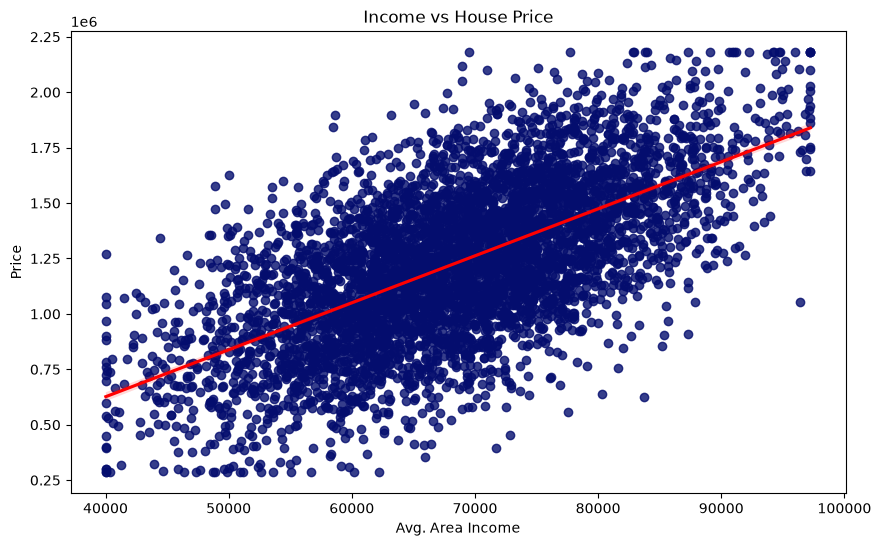

In [52]:
plt.figure(figsize=(10,6))
sns.regplot(x="Avg. Area Income",y="Price",data=df,scatter_kws={"color":"#040D6E"},line_kws={"color":"Red"})
plt.title("Income vs House Price")
plt.show()

House price increases with Average Area Income, showing a positive correlation between the variables.

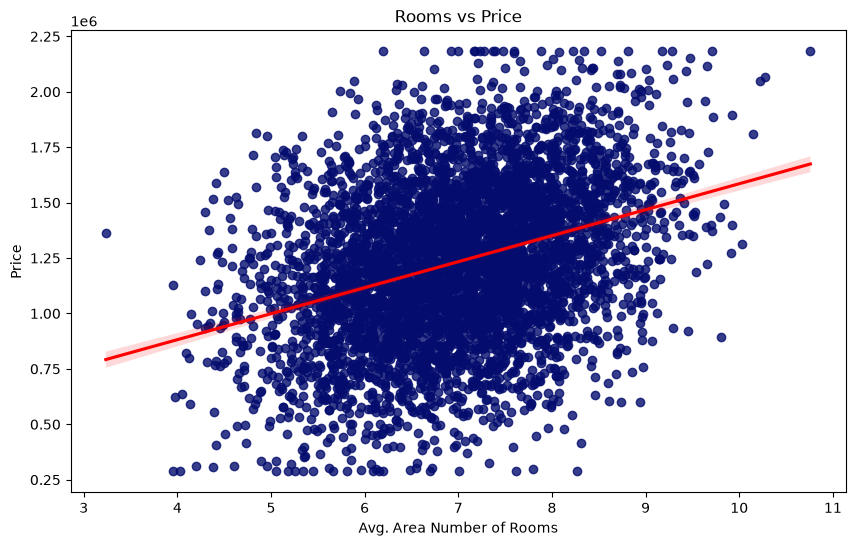

In [53]:
plt.figure(figsize=(10,6))
sns.regplot(x="Avg. Area Number of Rooms",y="Price",data=df,scatter_kws={"color":"#040D6E"},line_kws={"color":"Red"})
plt.title("Rooms vs Price")
plt.show()

The scatter plot shows a positive relationship between the average number of rooms and house price. Houses with more rooms generally tend to have higher prices. The upward regression line indicates a positive correlation between these variables.

## Multivariate Analysis

Text(0.5, 1.0, 'Correlation Heatmap')

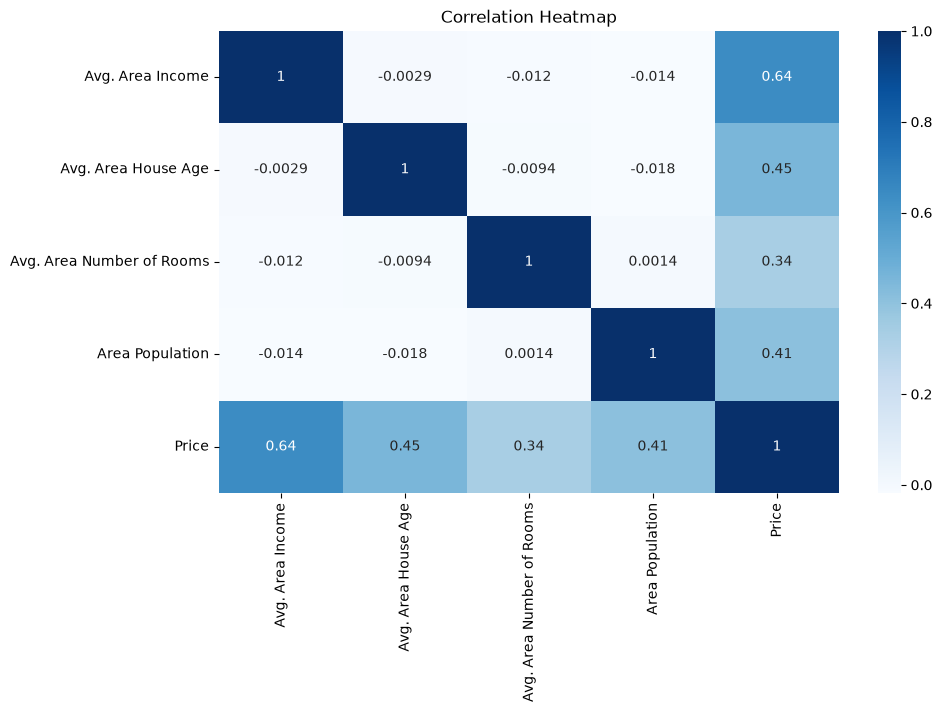

In [54]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="Blues")
plt.title("Correlation Heatmap")

Price vs Avg. Area Income = 0.64 → Higher income → Higher house price.

Price vs Avg. Area Number of Rooms = 0.46 → More rooms → Higher house price.

Price vs Avg. Area House Age = 0.45 → Older houses in developed areas → Higher house price.

Price vs Area Population = 0.41 → Larger population → Higher house price.

Price vs Avg. Area Number of Bedrooms = 0.17 → Weak positive relationship with price.

Strongest correlation visible: Price and Avg. Area Income (0.64).